In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print("\nShape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head())


Shape of dataset: (1092, 10)

Columns: ['timestamp', 'region', 'service_line', 'resource_demand', 'capacity_planned', 'operational_spend_usd', 'reliability_score', 'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score']

First 3 rows:
     timestamp         region service_line  resource_demand  capacity_planned  \
0  2024-01-01        East US      Compute           644.69               818   
1  2024-01-01        East US      Storage          1102.71              1400   
2  2024-01-01    West Europe      Compute           597.55               758   
3  2024-01-01    West Europe      Storage           979.71              1244   
4  2024-01-01  Central India      Compute           503.19               639   

   operational_spend_usd  reliability_score  gdp_growth_rate  \
0                 361.03             99.804             2.06   
1                 154.38             99.571             2.06   
2                 334.63             99.727             2.08   
3            

In [4]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 timestamp                 0
region                    0
service_line              0
resource_demand          22
capacity_planned          0
operational_spend_usd     0
reliability_score         0
gdp_growth_rate          22
tech_investment_index    22
cloud_sentiment_score     0
dtype: int64


In [5]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df = df.drop_duplicates()
print("\nDuplicates removed")


Duplicates removed


In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
print("\nColumn names standardized")


Column names standardized


In [8]:
for col in df.columns:
    if "date" in col or "time" in col:
        df[col] = pd.to_datetime(df[col])

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df = df[df[col] >= 0]

print("Negative values removed successfully")


Negative values removed successfully


In [10]:
for col in df.columns:
    if "date" in col or "time" in col:
        df["year"] = df[col].dt.year
        df["month"] = df[col].dt.month
        df["day"] = df[col].dt.day



Before Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500 

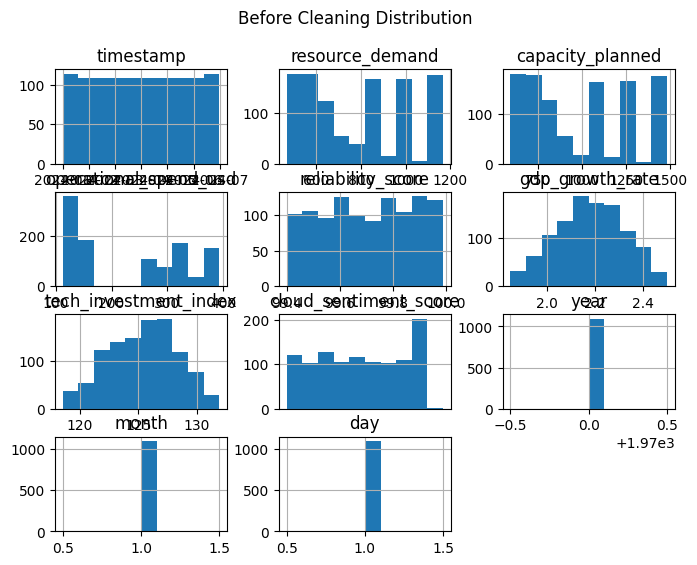

In [11]:
print("\nBefore Cleaning Summary:")
print(df.describe())
import matplotlib.pyplot as plt

df.hist(figsize=(8,6))
plt.suptitle("Before Cleaning Distribution")
plt.show()



After Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500  

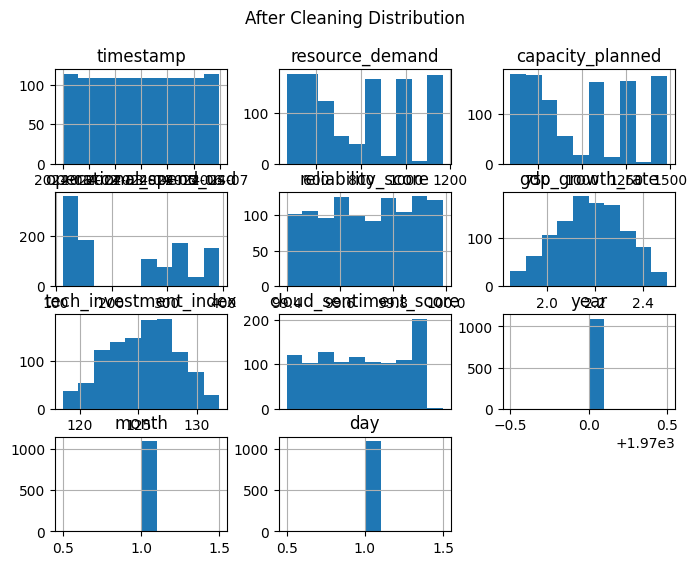

In [12]:
print("\nAfter Cleaning Summary:")
print(df.describe())

df.hist(figsize=(8,6))
plt.suptitle("After Cleaning Distribution")
plt.show()


In [13]:
df.to_csv("cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved successfully")


Cleaned dataset saved successfully


**MILESTONE - 2**

In [14]:
df = pd.read_csv("cleaned_dataset.csv")

print(df.columns)

Index(['timestamp', 'region', 'service_line', 'resource_demand',
       'capacity_planned', 'operational_spend_usd', 'reliability_score',
       'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score',
       'year', 'month', 'day'],
      dtype='object')


In [15]:
date_col = [col for col in df.columns if "date" in col or "time" in col][0]

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)
print(df)

      timestamp         region service_line  resource_demand  \
0    2024-01-01        East US      Compute           644.69   
1    2024-01-01        East US      Storage          1102.71   
2    2024-01-01    West Europe      Compute           597.55   
3    2024-01-01    West Europe      Storage           979.71   
4    2024-01-01  Central India      Compute           503.19   
...         ...            ...          ...              ...   
1086 2024-06-30        East US      Compute           811.35   
1087 2024-06-30        East US      Storage          1119.80   
1088 2024-06-30    West Europe      Compute           571.87   
1089 2024-06-30    West Europe      Storage           978.94   
1091 2024-06-30  Central India      Storage           854.08   

      capacity_planned  operational_spend_usd  reliability_score  \
0                  818                 361.03             99.804   
1                 1400                 154.38             99.571   
2                  758     

In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
print(df)

      timestamp         region service_line  resource_demand  \
0    2024-01-01        East US      Compute           644.69   
1    2024-01-01        East US      Storage          1102.71   
2    2024-01-01    West Europe      Compute           597.55   
3    2024-01-01    West Europe      Storage           979.71   
4    2024-01-01  Central India      Compute           503.19   
...         ...            ...          ...              ...   
1090 2024-06-30  Central India      Compute           518.73   
1086 2024-06-30        East US      Compute           811.35   
1087 2024-06-30        East US      Storage          1119.80   
1088 2024-06-30    West Europe      Compute           571.87   
1091 2024-06-30  Central India      Storage           854.08   

      capacity_planned  operational_spend_usd  reliability_score  \
0                  818                 361.03             99.804   
1                 1400                 154.38             99.571   
2                  758     

In [17]:
target = "resource_demand"

In [18]:
df["rolling_mean_7"] = df[target].rolling(7).mean()
df["rolling_std_7"] = df[target].rolling(7).std()

In [19]:
df["lag_1"] = df[target].shift(1)
df["lag_7"] = df[target].shift(7)
df["lag_14"] = df[target].shift(14)

In [20]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)
df["quarter"] = df["timestamp"].dt.quarter

In [21]:
threshold = df[target].mean() + 1.5 * df[target].std()

df["demand_spike_flag"] = df[target].apply(
    lambda x: 1 if x > threshold else 0
)

In [22]:
print(df.columns)

Index(['timestamp', 'region', 'service_line', 'resource_demand',
       'capacity_planned', 'operational_spend_usd', 'reliability_score',
       'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score',
       'year', 'month', 'day', 'rolling_mean_7', 'rolling_std_7', 'lag_1',
       'lag_7', 'lag_14', 'day_of_week', 'is_weekend', 'quarter',
       'demand_spike_flag'],
      dtype='object')


In [23]:
df = df.set_index("timestamp")

In [24]:
print(df.head())
print(df.index)

                   region service_line  resource_demand  capacity_planned  \
timestamp                                                                   
2024-01-01        East US      Compute           644.69               818   
2024-01-01        East US      Storage          1102.71              1400   
2024-01-01    West Europe      Compute           597.55               758   
2024-01-01    West Europe      Storage           979.71              1244   
2024-01-01  Central India      Compute           503.19               639   

            operational_spend_usd  reliability_score  gdp_growth_rate  \
timestamp                                                               
2024-01-01                 361.03             99.804             2.06   
2024-01-01                 154.38             99.571             2.06   
2024-01-01                 334.63             99.727             2.08   
2024-01-01                 137.16             99.887             2.08   
2024-01-01            

In [25]:
df.to_csv("milestone2_model_ready.csv", index=False)
print("Milestone 2 completed successfully.")

Milestone 2 completed successfully.


**MILESTONE 3**

In [26]:
!pip install xgboost statsmodels

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

In [28]:
df = pd.read_csv("milestone2_model_ready.csv")

print(df.head())
print(df.columns)

          region service_line  resource_demand  capacity_planned  \
0        East US      Compute           644.69               818   
1        East US      Storage          1102.71              1400   
2    West Europe      Compute           597.55               758   
3    West Europe      Storage           979.71              1244   
4  Central India      Compute           503.19               639   

   operational_spend_usd  reliability_score  gdp_growth_rate  \
0                 361.03             99.804             2.06   
1                 154.38             99.571             2.06   
2                 334.63             99.727             2.08   
3                 137.16             99.887             2.08   
4                 281.79             99.756             1.86   

   tech_investment_index          cloud_sentiment_score  year  ...  day  \
0                 121.92  1970-01-01 00:00:00.000000060  1970  ...    1   
1                 121.92  1970-01-01 00:00:00.000000060 

In [30]:
df["timestamp"] = pd.to_datetime(df[["year","month","day"]])

df = df.sort_values("timestamp")

print(df[["timestamp","resource_demand"]].head())

     timestamp  resource_demand
0   1970-01-01           644.69
719 1970-01-01           853.68
720 1970-01-01           686.87
721 1970-01-01          1154.01
722 1970-01-01           558.85


In [36]:
categorical_cols = ["region", "service_line", "cloud_sentiment_score"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category").cat.codes

print("Categorical columns encoded")

Categorical columns encoded


In [37]:
y = df["resource_demand"]

In [39]:
X = df.drop(columns=["resource_demand","timestamp"])

print(X.columns)

Index(['region', 'service_line', 'capacity_planned', 'operational_spend_usd',
       'reliability_score', 'gdp_growth_rate', 'tech_investment_index',
       'cloud_sentiment_score', 'year', 'month', 'day', 'rolling_mean_7',
       'rolling_std_7', 'lag_1', 'lag_7', 'lag_14', 'day_of_week',
       'is_weekend', 'quarter', 'demand_spike_flag'],
      dtype='object')


In [40]:
print(X.shape)
print(y.shape)

(1092, 20)
(1092,)


In [41]:
split_index = int(len(df)*0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (873, 20)
Test size: (219, 20)


In [42]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

print("XGBoost model trained")

XGBoost model trained


In [43]:
xgb_predictions = xgb_model.predict(X_test)

In [44]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 8.963185310537957
XGBoost RMSE: 32.64573375188347


In [45]:
arima_model = ARIMA(y_train, order=(2,1,2))

arima_fit = arima_model.fit()

print("ARIMA model trained")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA model trained


In [46]:
arima_forecast = arima_fit.forecast(steps=len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [47]:
mae_arima = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 195.56333812932138
ARIMA RMSE: 220.95436693879554


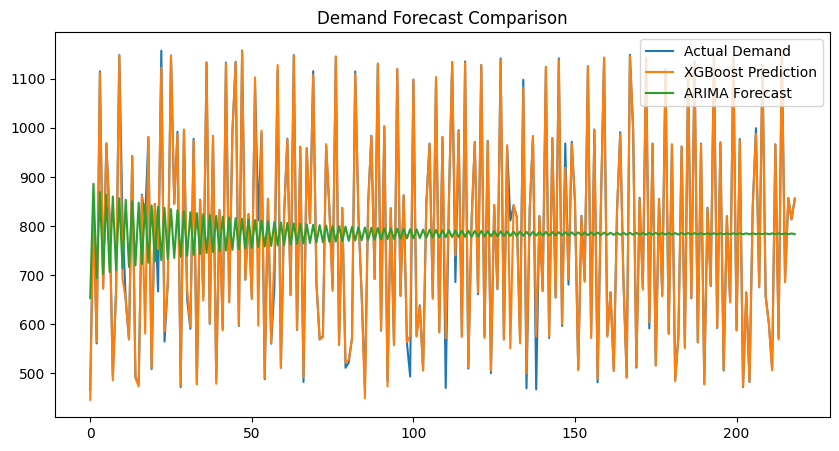

In [48]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Demand")
plt.plot(xgb_predictions, label="XGBoost Prediction")
plt.plot(arima_forecast.values, label="ARIMA Forecast")

plt.title("Demand Forecast Comparison")
plt.legend()

plt.show()